# Stochastic MPC for LinearLongitudinalB747

This notebook shows how to train and evaluate the stochastic `MPCAgent` on the `LinearLongitudinalB747-v0` environment. The workflow covers data collection under random disturbances, supervised training of the internal dynamics model, and a closed-loop MPC rollout with control-quality metrics.


In [1]:
import numpy as np
import torch
from tqdm import tqdm

import gymnasium as gym
import matplotlib.pyplot as plt

from tensoraerospace.agent.mpc.stochastic import MPCAgent, Net
from tensoraerospace.signals.random import full_random_signal
from tensoraerospace.signals.standart import unit_step
from tensoraerospace.utils import convert_tp_to_sec_tp, generate_time_period
from tensoraerospace.benchmark import ControlBenchmark


2025-12-24 03:46:35.038742: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-12-24 03:46:35.038772: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-12-24 03:46:35.039653: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-12-24 03:46:35.045120: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-24 03:46:35.889114: W tensorflow/compiler/tf2

In [2]:
SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)



In [3]:
dt = 0.1
simulation_time = 20

tp = generate_time_period(tn=simulation_time, dt=dt)
tps = convert_tp_to_sec_tp(tp, dt=dt)
number_time_steps = len(tp)

# Step reference (degrees) built on **seconds** timebase
reference_signal = np.reshape(
    unit_step(np.asarray(tps), degree=4, time_step=8, output_rad=False),
    (1, -1),
)

initial_state = np.array([0.0, 0.0, 0.0, 0.0], dtype=np.float32)

env = gym.make(
    "LinearLongitudinalB747-v0",
    number_time_steps=number_time_steps,
    initial_state=initial_state,
    reference_signal=reference_signal,
    dt=dt,
)

state, info = env.reset()
obs_dim = int(state.reshape(-1).shape[0])
action_dim = int(env.action_space.shape[0])
print(f"Observation shape: {state.shape} (obs_dim={obs_dim}), time steps: {number_time_steps}")
print(f"Action dim: {action_dim}")


Observation shape: (4, 1) (obs_dim=4), time steps: 201
Action dim: 1


/home/mr8bit/Projects/TensorAeroSpace/.venv/lib/python3.11/site-packages/gymnasium/utils/passive_env_checker.py:159: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


In [4]:
# Model/state layout for LinearLongitudinalB747 is [u, w, q, theta] (see aerospacemodel/B747).
IDX_Q = 2
IDX_THETA = 3


def tracking_cost(next_state, action, reference_signals=None, step=0):
    """Quadratic tracking cost (theta tracking) with mild q + action penalty."""
    if reference_signals is None:
        target_theta = torch.tensor(0.0, dtype=next_state.dtype)
    else:
        idx = min(step, reference_signals.shape[1] - 1)
        target_theta = torch.as_tensor(reference_signals[0, idx], dtype=next_state.dtype)

    theta_error = next_state[..., IDX_THETA] - target_theta
    q_penalty = 0.25 * (next_state[..., IDX_Q] ** 2)
    action_penalty = 0.01 * torch.norm(action)

    return (theta_error**2).mean() + q_penalty.mean() + action_penalty



In [5]:
# IMPORTANT: use the *actual* observation/action dimensions coming from env.reset/env.action_space
# (some environments return column vectors).
system_model = Net(
    num_action=action_dim,
    num_states=obs_dim,
)

agent = MPCAgent(
    gamma=0.99,
    action_dim=action_dim,
    observation_dim=obs_dim,
    model=system_model,
    cost_function=tracking_cost,
    env=env,
    min_max_action_value=(-15.0, 15.0),
    lr=1e-3,
)



In [6]:
# Safety defaults (in case you run this cell after a kernel restart / out of order)
ACTION_MAX_DEG = float(globals().get("ACTION_MAX_DEG", 25.0))
ACTION_NORM_RANGE = globals().get("ACTION_NORM_RANGE", (-1.0, 1.0))

# DATASET MODE:
# - env_rollouts: collect (s, a, s') from gym env using an exploration control signal
# - state_space_signals: generate synthetic transitions x_{t+1} = A x_t + B u_t
#   using many control signal shapes (copied + extended from transformer example)
DATASET_MODE = "state_space_signals"  # "env_rollouts" | "state_space_signals"

# Signal set copied from example-mpc-state-space-transformers.ipynb
# and extended with additional patterns available in DynamicsNN.generate_training_data.
CONTROL_SIGNALS = [
    "sine",
    "step",
    "sine_09",
    "sine_07",
    "sine_05_low_freq",
    "gaussian_noise",
    "uniform_noise",
    "linear_up",
    "linear_down",
    "sawtooth",
    "damped_sine",
    "chirp",
    "modulated_sine",
    "gaussian_pulse",
    "square_wave",
    "triangle_wave",
    "two_tone",
    "random_walk",
    "exponential",
    "constant_noise",
]

if DATASET_MODE == "env_rollouts":
    # Random exploration in *normalized* range [-1, 1], then scale to degrees for env.step
    exploration_signal_norm = full_random_signal(
        t0=0.0,
        dt=dt,
        tn=simulation_time,
        sd=(0.3, 0.8),
        sv=ACTION_NORM_RANGE,
    )

    exploration_signal_norm = np.asarray(exploration_signal_norm, dtype=np.float32).reshape(-1)
    exploration_signal_deg = (exploration_signal_norm * float(ACTION_MAX_DEG)).tolist()

    states, actions_deg, next_states = agent.collect_data(
        num_episodes=35,
        control_exploration_signal=exploration_signal_deg,
    )

    # Flatten column-vector observations into (N, obs_dim)
    states = states.reshape(states.shape[0], -1).astype(np.float32)
    next_states = next_states.reshape(next_states.shape[0], -1).astype(np.float32)

    actions_deg = np.asarray(actions_deg).reshape(-1, action_dim).astype(np.float32)
    actions = (actions_deg / float(ACTION_MAX_DEG)).astype(np.float32)

elif DATASET_MODE == "state_space_signals":
    from tensoraerospace.agent.mpc.dynamics import DynamicsNN
    import torch.nn as nn

    # More control signal types => use more samples so each pattern is represented.
    NUM_SAMPLES = 800_000

    # Use discrete-time matrices from the env model.
    A_d = torch.tensor(env.unwrapped.model.filt_A, dtype=torch.float32)
    B_d = torch.tensor(env.unwrapped.model.filt_B, dtype=torch.float32)

    # The model uses q/theta in radians internally, while env observations expose q/theta in degrees.
    rad2deg = 180.0 / np.pi
    deg2rad = np.pi / 180.0

    T = torch.diag(torch.tensor([1.0, 1.0, rad2deg, rad2deg], dtype=torch.float32))
    Tinv = torch.diag(torch.tensor([1.0, 1.0, deg2rad, deg2rad], dtype=torch.float32))

    # x_deg_next = A_deg x_deg + B_norm u_norm
    A_deg = T @ A_d @ Tinv
    B_deg_per_deg = (T @ B_d) * deg2rad
    B_norm = B_deg_per_deg * float(ACTION_MAX_DEG)

    # State ranges are in env observation units: [u (m/s), w (m/s), q (deg/s), theta (deg)]
    STATE_RANGES = [
        (-10.0, 10.0),
        (-10.0, 10.0),
        (-10.0, 10.0),
        (-15.0, 15.0),
    ]

    dyn_gen = DynamicsNN(nn.Linear(1, 1))
    states_t, actions_t, next_states_t = dyn_gen.generate_training_data(
        num_samples=NUM_SAMPLES,
        state_dim=obs_dim,
        control_dim=action_dim,
        state_ranges=STATE_RANGES,
        control_limits=ACTION_NORM_RANGE,
        control_signals=CONTROL_SIGNALS,
        A=A_deg,
        B=B_norm,
    )

    states = states_t.numpy().astype(np.float32)
    actions = actions_t.numpy().astype(np.float32)
    next_states = next_states_t.numpy().astype(np.float32)

else:
    raise ValueError(f"Unknown DATASET_MODE={DATASET_MODE}")

assert states.shape[1] == obs_dim, (states.shape, obs_dim)
assert actions.shape[1] == action_dim, (actions.shape, action_dim)

print(f"DATASET_MODE={DATASET_MODE}")
print(f"Collected {states.shape[0]} transitions")
print(f"Dataset shapes: states={states.shape}, actions={actions.shape}, next_states={next_states.shape}")


DATASET_MODE=state_space_signals
Collected 800000 transitions
Dataset shapes: states=(800000, 4), actions=(800000, 1), next_states=(800000, 4)


In [7]:
EPOCHS = 3500 if DATASET_MODE == "env_rollouts" else 800
BATCH_SIZE = 512 if DATASET_MODE == "env_rollouts" else 1024

agent.train_model(
    states=states,
    actions=actions,
    next_states=next_states,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
)



Loss 1.539844274520874:  44%|████▍     | 350/800 [09:27<12:10,  1.62s/it] 


KeyboardInterrupt: 

In [9]:
mpc_states = []
mpc_actions = []

# Safety default if you execute this cell out of order
ACTION_MAX_DEG = float(globals().get("ACTION_MAX_DEG", 25.0))

state, _ = env.reset()
mpc_states.append(state.reshape(-1))

reference_array = reference_signal
time_axis = []

MPC_ROLLOUT = 64
MPC_HORIZON = 5

max_steps = min(env.unwrapped.number_time_steps - 3, reference_array.shape[1] - 3)

for step in tqdm(range(max_steps), desc="MPC rollout"):
    action_norm, _ = agent.choose_action_ref(
        state.reshape(-1),
        rollout=MPC_ROLLOUT,
        horizon=MPC_HORIZON,
        reference_signals=reference_array,
        step=step,
    )

    # `action_norm` is returned as shape (1, action_dim) in [-1, 1]
    action_norm_1d = np.asarray(action_norm, dtype=np.float32).reshape(-1)
    action_deg = action_norm_1d * float(ACTION_MAX_DEG)

    # env expects degrees
    next_state, reward, terminated, truncated, _ = env.step(action_deg)

    mpc_actions.append(float(action_deg[0]))
    mpc_states.append(next_state.reshape(-1))
    time_axis.append(step * dt)

    state = next_state
    if terminated or truncated:
        break

mpc_states = np.array(mpc_states).reshape(len(mpc_states), -1)
mpc_actions = np.array(mpc_actions)
time_axis = np.array(time_axis)
print(f"Simulated {len(mpc_states)} steps")


MPC rollout: 100%|██████████| 198/198 [00:15<00:00, 12.43it/s]

Simulated 199 steps


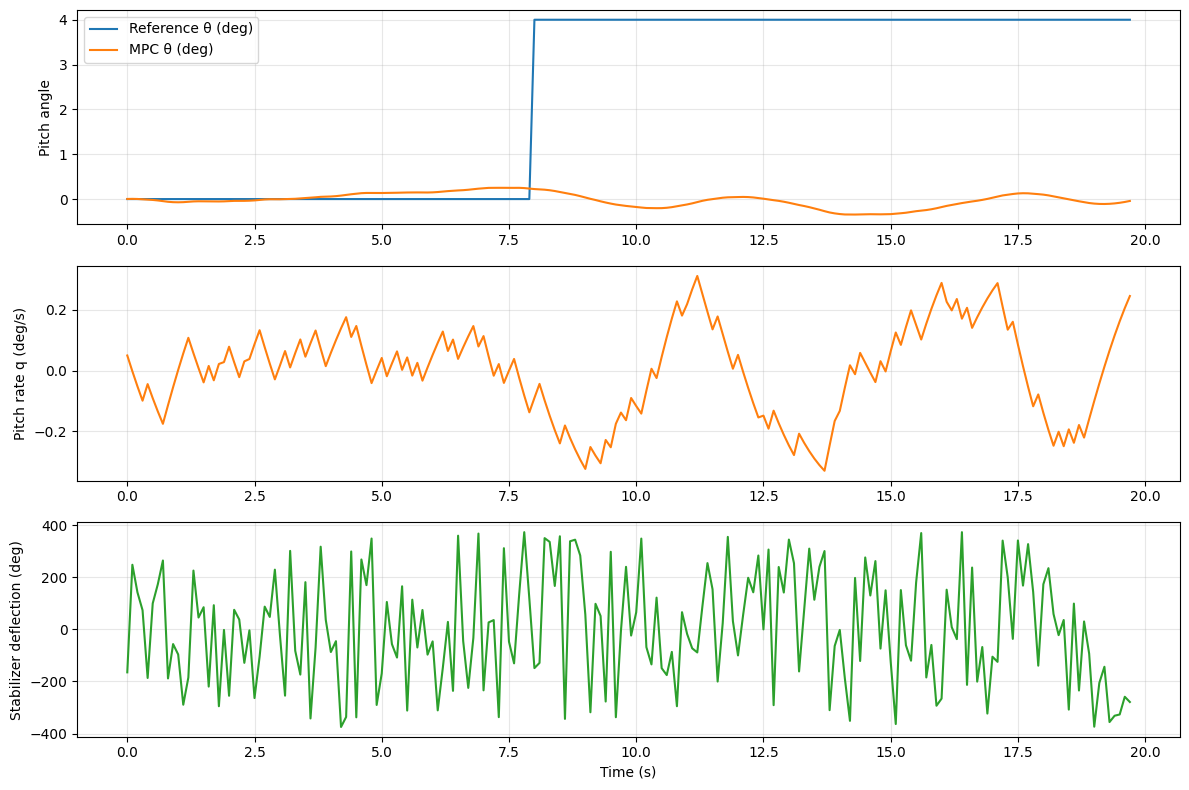

In [10]:
plot_len = min(len(time_axis), reference_signal.shape[1] - 1)

theta_ref = reference_signal[0, :plot_len]
theta_actual = mpc_states[1 : plot_len + 1, IDX_THETA]
q_actual = mpc_states[1 : plot_len + 1, IDX_Q]

plt.figure(figsize=(12, 8))
plt.subplot(3, 1, 1)
plt.plot(time_axis[:plot_len], theta_ref, label="Reference θ (deg)")
plt.plot(time_axis[:plot_len], theta_actual, label="MPC θ (deg)")
plt.ylabel("Pitch angle")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(3, 1, 2)
plt.plot(time_axis[:plot_len], q_actual, color="tab:orange")
plt.ylabel("Pitch rate q (deg/s)")
plt.grid(True, alpha=0.3)

plt.subplot(3, 1, 3)
plt.plot(time_axis[:plot_len], mpc_actions[:plot_len], color="tab:green")
plt.xlabel("Time (s)")
plt.ylabel("Stabilizer deflection (deg)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



In [16]:
benchmark = ControlBenchmark()
metrics = benchmark.becnchmarking_one_step(
    control_signal=theta_ref,
    system_signal=theta_actual,
    signal_val=0.1,
    dt=dt,
)

for name, value in metrics.items():
    print(f"{name:>20s}: {value}")



           overshoot: -20.52924633026123
       settling_time: 11.8
      damping_degree: 0.3495543897151947
        static_error: 1.1401586532592773
           rise_time: None
           peak_time: 0.1
   maximum_deviation: 4.50614595413208
                 iae: 324.4539724793285
                 ise: 1006.7461336328329
                itae: 1615.6035354375838
   oscillation_count: 7
  steady_state_value: 4.0
   performance_index: 1053.045716894219


## Notes

- Adjust `num_episodes`, `epochs`, `rollout`, and `horizon` to trade off sample efficiency and runtime.
- The same workflow applies to other longitudinal aerospace models—only the environment configuration and cost shaping need to change.
